# 06 — Feature Engineering: Revenue & Monetization (Zahra)
**Tujuan:** Membuat fitur efisiensi pendapatan dan monetisasi konten YouTube.  
**Output:** `data/processed/features_revenue.csv`  
**Digunakan oleh:** M1-Regression, M4-RootCause, M5-Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
df = pd.read_csv('../../data/cleaned/abis_cleaning.csv')
df = df.drop_duplicates(subset=['video_id'], keep='first').reset_index(drop=True)

df['views']              = df['penayangan_tak_dilewati']
df['revenue_idr']        = df['estimasi_pendapatan_idr']
df['subscriber_gained']  = df['subscriber_yang_diperoleh']
df['watch_time_hours']   = df['waktu_tonton_jam']
df['adsense_idr']        = df['estimasi_pendapatan_adsense_idr']
df['ad_impressions']     = df['tayangan_iklan']
df['rpm_idr']            = df['rpm_idr']
df['cpm_idr']            = df['cpm_idr']
df['youtube_premium_idr']= df['youtube_premium_idr']

print(f"Shape: {df.shape}")
print(df[['views','revenue_idr','rpm_idr','cpm_idr','ad_impressions']].describe().round(2))

Shape: (2355, 54)
            views  revenue_idr   rpm_idr   cpm_idr  ad_impressions
count     2355.00      2355.00   2355.00   2218.00         2218.00
mean     42805.18    144810.44   3627.49   8198.19        34478.74
std      95498.31    377717.72   1708.04   1869.83        80112.16
min         19.00        85.56    140.04   4168.06           16.00
25%       4915.00     16461.45   2642.77   7177.29         4167.50
50%      12755.00     43016.21   3400.47   7945.52        10588.50
75%      37527.00    118940.68   4465.80   8863.42        29488.25
max    1515626.00   7002860.04  19334.98  37266.91      1231622.00


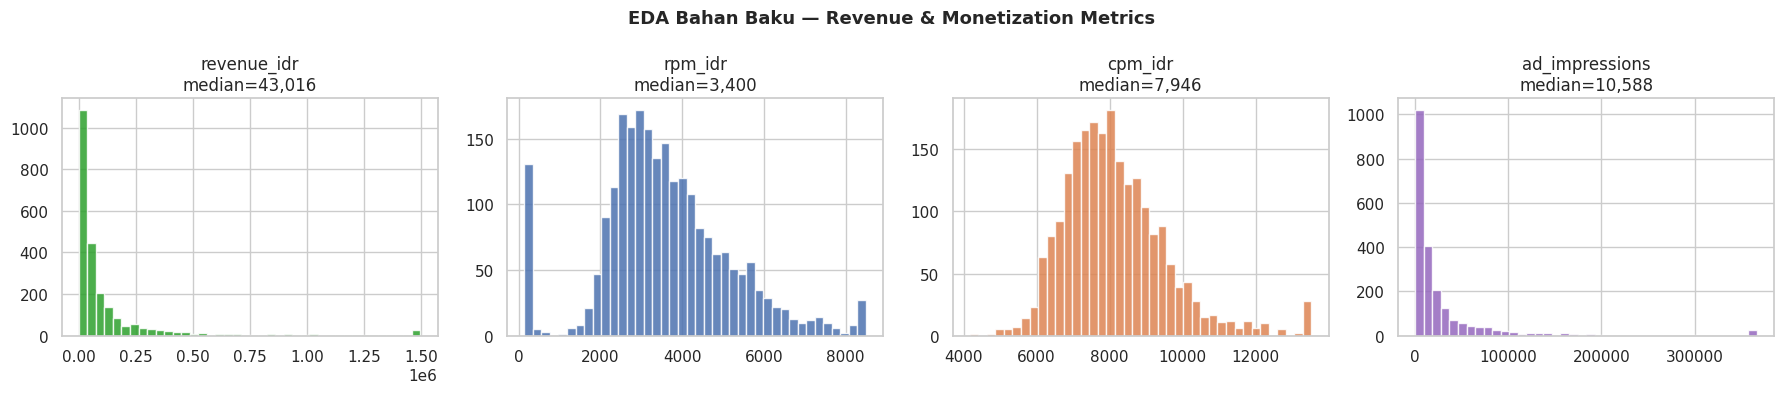

Video dengan revenue > 0: 2355 (100.0%)


In [3]:
# ── 2. EDA BAHAN BAKU ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('EDA Bahan Baku — Revenue & Monetization Metrics', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes,
    ['revenue_idr','rpm_idr','cpm_idr','ad_impressions'],
    ['#2ca02c','#4C72B0','#DD8452','#9467BD']):
    vals = df[col].dropna()
    vals_clipped = vals.clip(0, vals.quantile(0.99))
    ax.hist(vals_clipped, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}\nmedian={vals.median():,.0f}')

plt.tight_layout()
plt.show()

print(f"Video dengan revenue > 0: {(df['revenue_idr'] > 0).sum()} ({(df['revenue_idr'] > 0).mean()*100:.1f}%)")

In [4]:
# ── 3. FEATURE COMPUTATION ───────────────────────────────────────────────────
EPS = 1

# Efisiensi pendapatan per unit
df['revenue_per_view']        = df['revenue_idr'] / (df['views'] + EPS)
df['revenue_per_subscriber']  = df['revenue_idr'] / (df['subscriber_gained'].abs() + EPS)
df['revenue_per_watchhour']   = df['revenue_idr'] / (df['watch_time_hours'] + EPS)

# Komposisi pendapatan
df['adsense_share']           = df['adsense_idr'] / (df['revenue_idr'] + EPS)
df['premium_share']           = df['youtube_premium_idr'] / (df['revenue_idr'] + EPS)

# Efisiensi iklan
df['ad_impression_rate']      = df['ad_impressions'] / (df['views'] + EPS)
df['monetization_efficiency'] = df['rpm_idr'] / (df['cpm_idr'] + EPS)  # RPM/CPM ratio

# Flags
df['is_monetized']            = (df['revenue_idr'] > 0).astype(int)

# Kategori pendapatan (0=rendah, 1=sedang, 2=tinggi)
df['revenue_category'] = pd.qcut(
    df['revenue_idr'].rank(method='first'), 3,
    labels=[0, 1, 2]
).astype(int)

# Log revenue (untuk model linear)
df['revenue_idr_log']         = np.log1p(df['revenue_idr'])

print("Revenue features computed ✓")
df[['revenue_per_view','adsense_share','ad_impression_rate','monetization_efficiency']].describe().round(4)

Revenue features computed ✓


,revenue_per_view,adsense_share,ad_impression_rate,monetization_efficiency
count,2355.0000,2355.0000,2218.0000,2218.0000
mean,3.6253,0.9188,0.8178,0.4604
std,1.7062,0.2307,0.2160,0.1210
min,0.1398,0.0000,0.0117,0.0080
25%,2.6400,0.9689,0.6531,0.3695
50%,3.3998,0.9826,0.8000,0.4502
75%,4.4646,0.9893,0.9511,0.5331
max,19.3124,0.9998,2.2733,1.2607


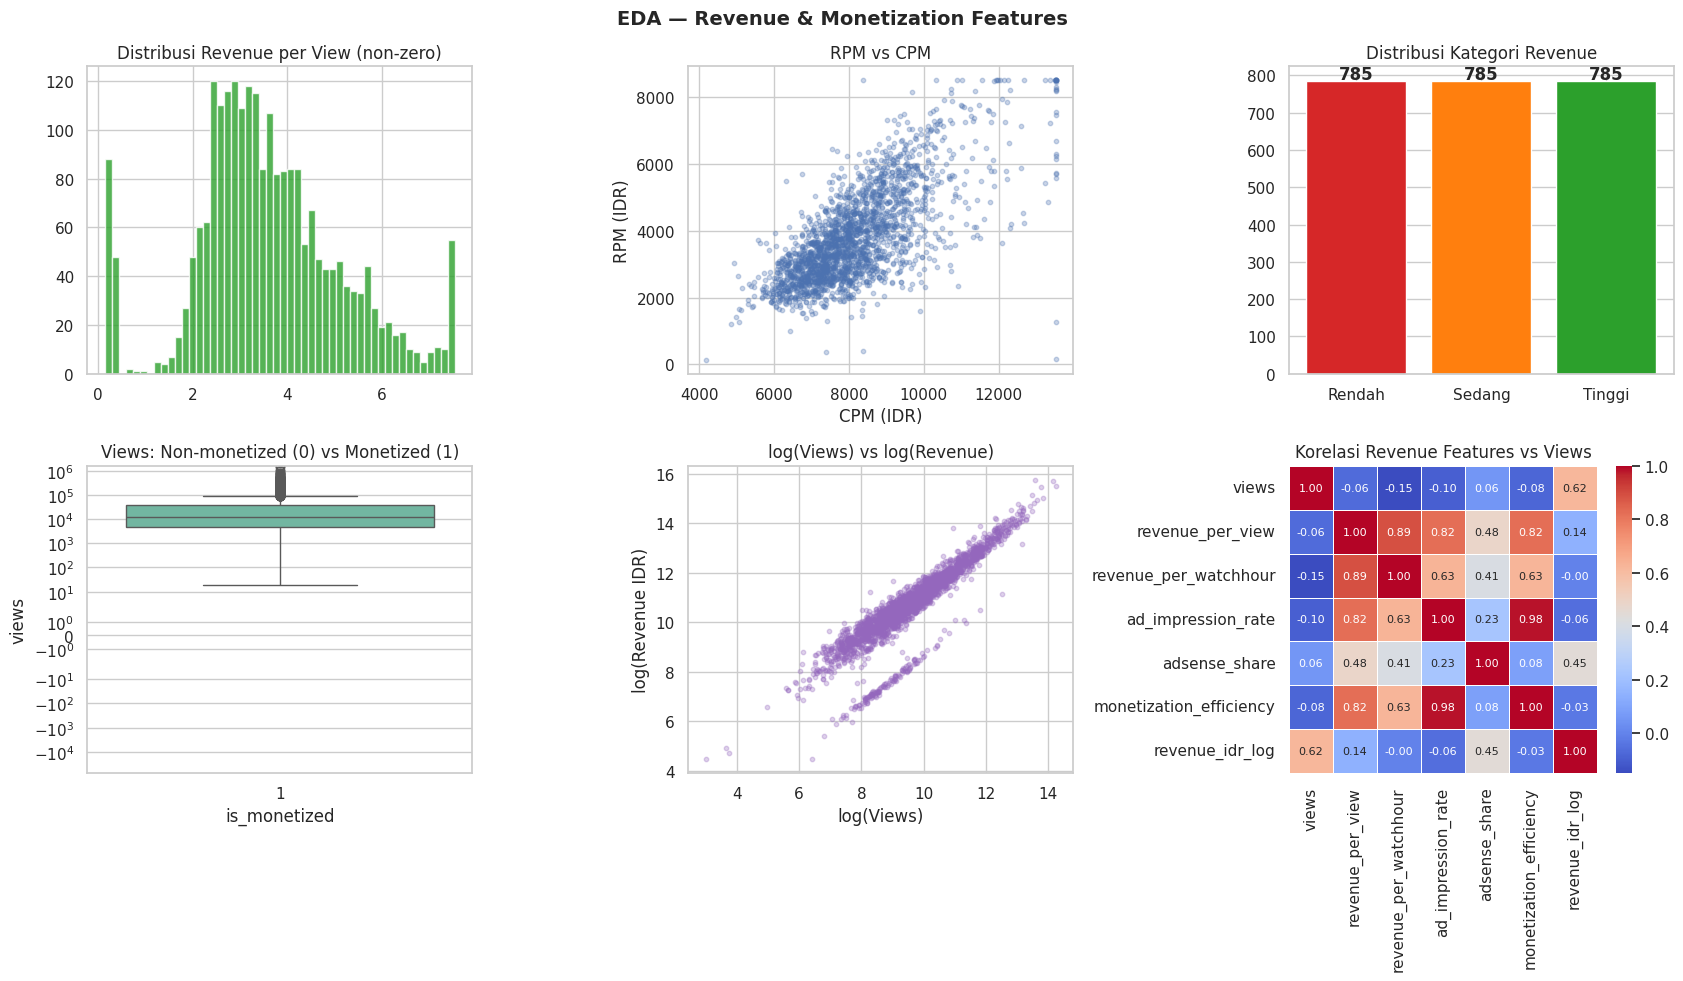

In [5]:
# ── 4. EDA FITUR REVENUE ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('EDA — Revenue & Monetization Features', fontsize=14, fontweight='bold')

# (A) Revenue per view distribution
axes[0][0].hist(df[df['revenue_per_view']>0]['revenue_per_view']
                .clip(0, df['revenue_per_view'].quantile(0.98)),
                bins=50, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[0][0].set_title('Distribusi Revenue per View (non-zero)')

# (B) RPM vs CPM scatter
axes[0][1].scatter(df['cpm_idr'].clip(0, df['cpm_idr'].quantile(0.99)),
                   df['rpm_idr'].clip(0, df['rpm_idr'].quantile(0.99)),
                   alpha=0.3, s=10, color='#4C72B0')
axes[0][1].set_title('RPM vs CPM'); axes[0][1].set_xlabel('CPM (IDR)'); axes[0][1].set_ylabel('RPM (IDR)')

# (C) Revenue category distribution
cat_counts = df['revenue_category'].value_counts().sort_index()
axes[0][2].bar(['Rendah','Sedang','Tinggi'], cat_counts.values,
               color=['#d62728','#ff7f0e','#2ca02c'], edgecolor='white')
axes[0][2].set_title('Distribusi Kategori Revenue')
for i, v in enumerate(cat_counts.values):
    axes[0][2].text(i, v+5, str(v), ha='center', fontweight='bold')

# (D) Monetized vs non-monetized
sns.boxplot(data=df, x='is_monetized', y='views', palette='Set2', ax=axes[1][0])
axes[1][0].set_yscale('symlog')
axes[1][0].set_title('Views: Non-monetized (0) vs Monetized (1)')

# (E) Revenue vs views scatter
axes[1][1].scatter(np.log1p(df['views']), np.log1p(df['revenue_idr']),
                   alpha=0.3, s=10, color='#9467BD')
axes[1][1].set_title('log(Views) vs log(Revenue)')
axes[1][1].set_xlabel('log(Views)'); axes[1][1].set_ylabel('log(Revenue IDR)')

# (F) Correlation heatmap
feat = ['views','revenue_per_view','revenue_per_watchhour','ad_impression_rate',
        'adsense_share','monetization_efficiency','revenue_idr_log']
corr = df[feat].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1][2],
            linewidths=0.5, annot_kws={'size':8})
axes[1][2].set_title('Korelasi Revenue Features vs Views')

plt.tight_layout()
plt.show()

In [6]:
# ── 5. VALIDASI & EXPORT ─────────────────────────────────────────────────────
rev_cols = [
    'video_id',
    'revenue_per_view', 'revenue_per_subscriber', 'revenue_per_watchhour',
    'adsense_share', 'premium_share',
    'ad_impression_rate', 'monetization_efficiency',
    'is_monetized', 'revenue_category', 'revenue_idr_log'
]
df_out = df[rev_cols].copy()
df_out = df_out.replace([np.inf, -np.inf], np.nan).fillna(0)
df_out[['adsense_share','premium_share']] = df_out[['adsense_share','premium_share']].clip(0, 1)

print(f"Shape: {df_out.shape} | Nulls: {df_out.isnull().sum().sum()}")
display(df_out.head(3))

import os
output_path = '../../data/processed/features_revenue.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_out.to_csv(output_path, index=False)
print(f"\n✅ Tersimpan: {output_path}")

Shape: (2355, 11) | Nulls: 0


,video_id,revenue_per_view,revenue_per_subscriber,revenue_per_watchhour,adsense_share,premium_share,ad_impression_rate,monetization_efficiency,is_monetized,revenue_category,revenue_idr_log
0,jkL6Ii5d4hI,2.390087,733.802045,39.551489,0.964538,0.013441,0.670232,0.382126,1,2,13.857356
1,mIeRGD4KT-A,2.970985,778.543668,46.574516,0.957754,0.021738,0.730824,0.419644,1,2,13.935365
2,XCRg3dGQqd8,3.945063,1297.773047,69.716924,0.931028,0.034773,0.742881,0.438831,1,2,14.134430



✅ Tersimpan: ../../data/processed/features_revenue.csv
